# CPU Usage — Multi-Horizon Forecast (CatBoost)
10 моделей × 15 секунд = прогноз на 2.5 минуты вперёд.
Каждая модель оптимизирована под свой горизонт — нет накопления ошибок.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings, json, os
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/cpu_dataset.csv')
df = df.sort_values('timestamp').reset_index(drop=True)
df['dt'] = pd.to_datetime(df['timestamp'], unit='s', utc=True)

print(f'Shape: {df.shape}')
print(df['cpu_usage_percent'].describe())

Shape: (24329, 3)
count    24329.000000
mean        51.849760
std         21.706086
min         18.552542
25%         24.443220
50%         54.753083
75%         69.650000
max         99.616102
Name: cpu_usage_percent, dtype: float64


In [10]:
STEP_SEC     = 15                     # интервал сбора данных
HORIZONS     = list(range(1, 11))    # 1..10 шагов → 15s..150s
LAGS         = [1, 2, 3, 4, 5, 8, 12, 16, 20, 24]
ROLL_WINDOWS = [4, 8, 12, 20]

def create_features(df, horizon, lags=LAGS, windows=ROLL_WINDOWS):
    d = df.copy()
    for lag in lags:
        d[f'cpu_lag_{lag}'] = d['cpu_usage_percent'].shift(lag)
    for w in windows:
        d[f'cpu_rmean_{w}'] = d['cpu_usage_percent'].rolling(w).mean()
        d[f'cpu_rstd_{w}']  = d['cpu_usage_percent'].rolling(w).std()
        d[f'cpu_rmin_{w}']  = d['cpu_usage_percent'].rolling(w).min()
        d[f'cpu_rmax_{w}']  = d['cpu_usage_percent'].rolling(w).max()
    d['cpu_diff_1']  = d['cpu_usage_percent'].diff(1)
    d['cpu_diff_2']  = d['cpu_usage_percent'].diff(2)
    d['cpu_ewm_4']   = d['cpu_usage_percent'].ewm(span=4,  adjust=False).mean()
    d['cpu_ewm_12']  = d['cpu_usage_percent'].ewm(span=12, adjust=False).mean()
    d['cpu_target']  = d['cpu_usage_percent'].shift(-horizon)
    return d

FEATURE_COLS = (
    [f'cpu_lag_{l}' for l in LAGS] +
    [f'cpu_rmean_{w}' for w in ROLL_WINDOWS] +
    [f'cpu_rstd_{w}'  for w in ROLL_WINDOWS] +
    [f'cpu_rmin_{w}'  for w in ROLL_WINDOWS] +
    [f'cpu_rmax_{w}'  for w in ROLL_WINDOWS] +
    ['cpu_diff_1', 'cpu_diff_2', 'cpu_ewm_4', 'cpu_ewm_12']
)
print(f'Features: {len(FEATURE_COLS)}')
print(f'Horizons: {HORIZONS} steps = {[h*STEP_SEC for h in HORIZONS]} seconds')

Features: 30
Horizons: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] steps = [15, 30, 45, 60, 75, 90, 105, 120, 135, 150] seconds


In [11]:
def stratified_split(df_clean, ratio=0.8):
    df_clean = df_clean.copy()
    df_clean['hour'] = pd.to_datetime(df_clean['timestamp'], unit='s').dt.hour
    train_dfs, test_dfs = [], []
    for hour in sorted(df_clean['hour'].unique()):
        hd = df_clean[df_clean['hour'] == hour].reset_index(drop=True)
        idx = int(len(hd) * ratio)
        train_dfs.append(hd[:idx])
        test_dfs.append(hd[idx:])
    train = pd.concat(train_dfs).sort_values('timestamp').reset_index(drop=True)
    test  = pd.concat(test_dfs ).sort_values('timestamp').reset_index(drop=True)
    return train, test

In [12]:
models  = {}   # h -> CatBoostRegressor
metrics = {}   # h -> dict

os.makedirs('../models', exist_ok=True)

for h in HORIZONS:
    df_h = create_features(df, horizon=h).dropna().reset_index(drop=True)
    train, test = stratified_split(df_h)

    X_tr, y_tr = train[FEATURE_COLS], train['cpu_target']
    X_te, y_te = test[FEATURE_COLS],  test['cpu_target']

    model = CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=7,
        loss_function='RMSE',
        eval_metric='MAE',
        verbose=0,
        random_state=42,
        task_type='CPU'
    )
    model.fit(Pool(X_tr, y_tr), eval_set=Pool(X_te, y_te))

    pred = np.clip(model.predict(X_te), 0, 100)
    mae  = mean_absolute_error(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    r2   = r2_score(y_te, pred)

    models[h]  = model
    metrics[h] = {'mae': mae, 'rmse': rmse, 'r2': r2,
                  'horizon_sec': h * STEP_SEC}

    model.save_model(f'../models/cpu_model_h{h:02d}.cbm')
    print(f'h={h:2d} ({h*STEP_SEC:3d}s)  MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}')

print('\nAll models trained and saved.')

h= 1 ( 15s)  MAE=0.2842  RMSE=0.4142  R2=0.9996
h= 2 ( 30s)  MAE=0.3580  RMSE=0.5130  R2=0.9994
h= 3 ( 45s)  MAE=0.4262  RMSE=0.6051  R2=0.9992
h= 4 ( 60s)  MAE=0.4887  RMSE=0.7129  R2=0.9989
h= 5 ( 75s)  MAE=0.5661  RMSE=0.8404  R2=0.9985
h= 6 ( 90s)  MAE=0.6296  RMSE=0.9577  R2=0.9981
h= 7 (105s)  MAE=0.7052  RMSE=1.0850  R2=0.9975
h= 8 (120s)  MAE=0.7784  RMSE=1.2147  R2=0.9969
h= 9 (135s)  MAE=0.8416  RMSE=1.3405  R2=0.9962
h=10 (150s)  MAE=0.9035  RMSE=1.4753  R2=0.9954

All models trained and saved.


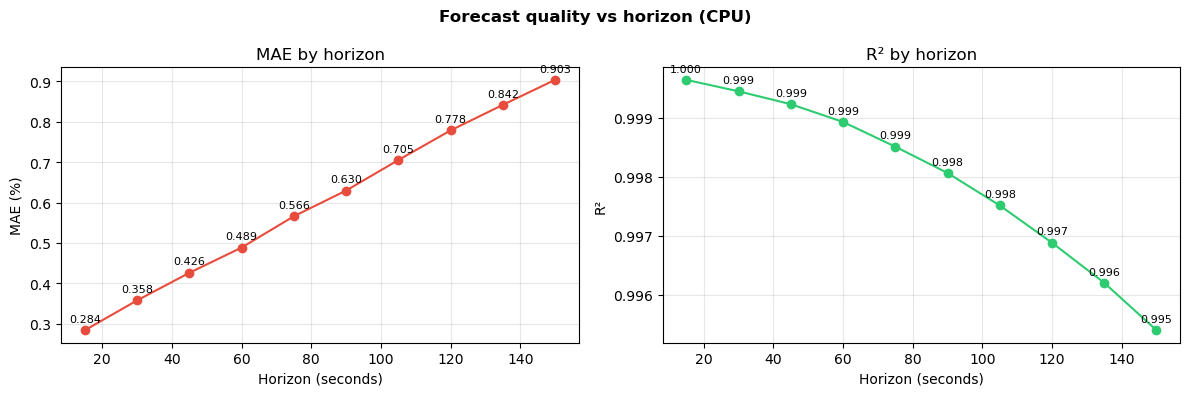

In [13]:
# График деградации качества с ростом горизонта
hs   = list(metrics.keys())
maes = [metrics[h]['mae'] for h in hs]
r2s  = [metrics[h]['r2']  for h in hs]
secs = [h * STEP_SEC for h in hs]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Forecast quality vs horizon (CPU)', fontweight='bold')

ax1.plot(secs, maes, 'o-', color='#e74c3c')
ax1.set_xlabel('Horizon (seconds)')
ax1.set_ylabel('MAE (%)')
ax1.set_title('MAE by horizon')
ax1.grid(True, alpha=0.3)
for x, y in zip(secs, maes):
    ax1.annotate(f'{y:.3f}', (x, y), textcoords='offset points',
                 xytext=(0, 6), ha='center', fontsize=8)

ax2.plot(secs, r2s, 'o-', color='#2ecc71')
ax2.set_xlabel('Horizon (seconds)')
ax2.set_ylabel('R²')
ax2.set_title('R² by horizon')
ax2.grid(True, alpha=0.3)
for x, y in zip(secs, r2s):
    ax2.annotate(f'{y:.3f}', (x, y), textcoords='offset points',
                 xytext=(0, 6), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

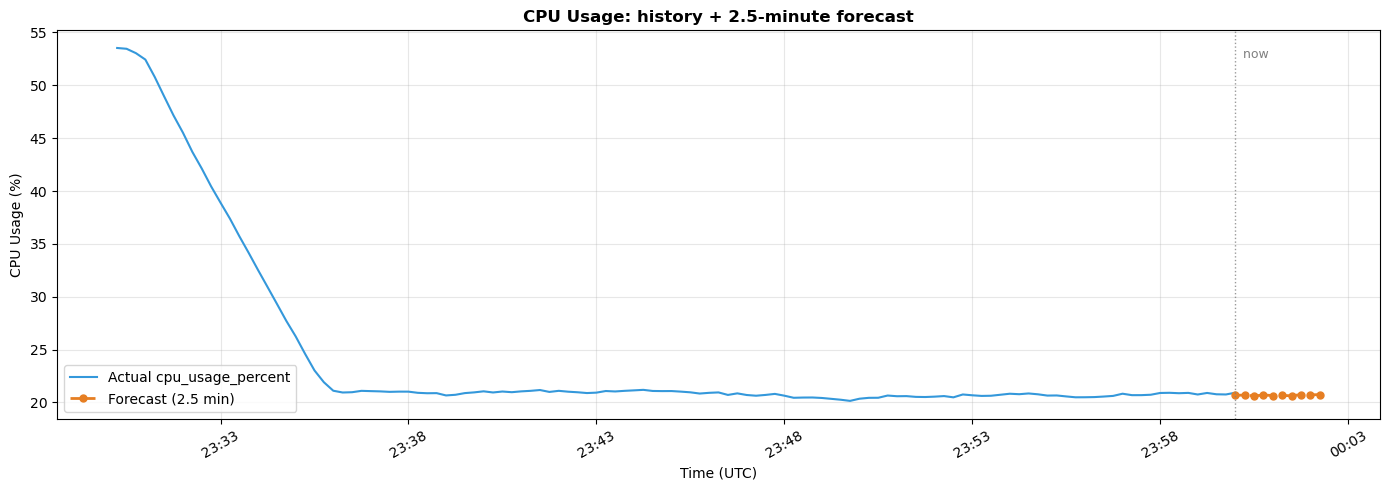

Forecast values:
  00:00:00  cpu_usage_percent = 20.663%
  00:00:15  cpu_usage_percent = 20.700%
  00:00:30  cpu_usage_percent = 20.616%
  00:00:45  cpu_usage_percent = 20.698%
  00:01:00  cpu_usage_percent = 20.652%
  00:01:15  cpu_usage_percent = 20.655%
  00:01:30  cpu_usage_percent = 20.630%
  00:01:45  cpu_usage_percent = 20.739%
  00:02:00  cpu_usage_percent = 20.711%
  00:02:15  cpu_usage_percent = 20.741%


In [14]:
def build_forecast(df_source, models, feature_cols, horizons, step_sec=15,
                   history_points=120):
    """
    Строит прогноз: history_points реальных значений + прогноз на len(horizons) шагов.
    df_source — исходный df с колонками timestamp, cpu_usage_percent, dt.
    """
    max_lag  = max(LAGS)
    max_roll = max(ROLL_WINDOWS)
    buf_size = history_points + max(max_lag, max_roll) + 5
    buf = df_source.tail(buf_size).copy().reset_index(drop=True)

    buf_feat = create_features(buf, horizon=1)
    last_row = buf_feat.dropna().iloc[[-1]]

    last_ts     = last_row['timestamp'].values[0]
    future_ts   = [last_ts + h * step_sec for h in horizons]
    future_vals = []
    for h in horizons:
        pred = float(np.clip(models[h].predict(last_row[feature_cols]), 0, 100))
        future_vals.append(pred)

    hist     = df_source.tail(history_points).copy()
    hist_dt  = pd.to_datetime(hist['timestamp'].values, unit='s', utc=True)
    future_dt = pd.to_datetime(future_ts, unit='s', utc=True)

    return hist_dt, hist['cpu_usage_percent'].values, future_dt, np.array(future_vals), last_row


# Используем последние данные из датасета как «текущий момент»
hist_dt, hist_vals, future_dt, future_vals, _ = build_forecast(
    df, models, FEATURE_COLS, HORIZONS
)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(hist_dt, hist_vals,
        color='#3498db', linewidth=1.5, label='Actual cpu_usage_percent')

join_dt  = [hist_dt[-1],   future_dt[0]]
join_val = [hist_vals[-1], future_vals[0]]
ax.plot(join_dt, join_val, color='#e67e22', linewidth=2, linestyle='--')

ax.plot(future_dt, future_vals,
        color='#e67e22', linewidth=2, linestyle='--',
        marker='o', markersize=5, label='Forecast (2.5 min)')

ax.axvline(hist_dt[-1], color='gray', linewidth=1, linestyle=':', alpha=0.8)
ax.text(hist_dt[-1], ax.get_ylim()[1] * 0.97, '  now',
        color='gray', fontsize=9, va='top')

ax.set_title('CPU Usage: history + 2.5-minute forecast', fontweight='bold')
ax.set_ylabel('CPU Usage (%)')
ax.set_xlabel('Time (UTC)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
plt.xticks(rotation=30)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Forecast values:')
for dt, v in zip(future_dt, future_vals):
    print(f'  {dt.strftime("%H:%M:%S")}  cpu_usage_percent = {v:.3f}%')

In [15]:
def forecast_from_prometheus(raw_df, models, feature_cols, horizons,
                              step_sec=15, history_points=120):
    """
    raw_df: DataFrame с колонками ['timestamp', 'cpu_usage_percent']
            (то, что возвращает скрипт сбора данных)
    Возвращает DataFrame с прогнозом.
    """
    raw_df = raw_df.sort_values('timestamp').reset_index(drop=True)
    raw_df['dt'] = pd.to_datetime(raw_df['timestamp'], unit='s', utc=True)

    hist_dt, hist_vals, future_dt, future_vals, _ = build_forecast(
        raw_df, models, feature_cols, horizons, step_sec, history_points
    )

    forecast_df = pd.DataFrame({
        'dt': future_dt,
        'cpu_usage_forecast': future_vals,
        'horizon_sec': [h * step_sec for h in horizons]
    })
    return forecast_df


# Пример использования
forecast_df = forecast_from_prometheus(df, models, FEATURE_COLS, HORIZONS)
print(forecast_df.to_string(index=False))

                       dt  cpu_usage_forecast  horizon_sec
2026-05-30 00:00:00+00:00           20.663092           15
2026-05-30 00:00:15+00:00           20.699715           30
2026-05-30 00:00:30+00:00           20.616260           45
2026-05-30 00:00:45+00:00           20.698280           60
2026-05-30 00:01:00+00:00           20.651842           75
2026-05-30 00:01:15+00:00           20.654680           90
2026-05-30 00:01:30+00:00           20.629988          105
2026-05-30 00:01:45+00:00           20.738563          120
2026-05-30 00:02:00+00:00           20.711003          135
2026-05-30 00:02:15+00:00           20.741433          150


In [16]:
with open('../models/cpu_multi_horizon_config.json', 'w') as f:
    json.dump({
        'feature_cols':  FEATURE_COLS,
        'horizons':      HORIZONS,
        'step_sec':      STEP_SEC,
        'lags':          LAGS,
        'roll_windows':  ROLL_WINDOWS,
        'model_files':   [f'cpu_model_h{h:02d}.cbm' for h in HORIZONS],
        'metrics':       {str(h): metrics[h] for h in HORIZONS}
    }, f, indent=2)
print('Config saved: cpu_multi_horizon_config.json')
print(f'Total models saved: {len(HORIZONS)}')

Config saved: cpu_multi_horizon_config.json
Total models saved: 10
